In [1]:
# ============================================================
# APP_TEST.IPYNB — ZELLE 1: Imports & Daten laden
# Ziel: Alle Funktionen der Streamlit App testen
#       bevor sie in app.py übertragen werden
# ============================================================
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import os
from datetime import date, timedelta

# Farb-Fix Windows 125% Skalierung
matplotlib.rcParams['text.color']        = 'black'
matplotlib.rcParams['axes.labelcolor']   = 'black'
matplotlib.rcParams['xtick.color']       = 'black'
matplotlib.rcParams['ytick.color']       = 'black'
matplotlib.rcParams['figure.facecolor']  = 'white'
matplotlib.rcParams['axes.facecolor']    = 'white'
matplotlib.rcParams['savefig.facecolor'] = 'white'
matplotlib.rcParams['font.family']       = 'DejaVu Sans'

# --- Pfade ---
DATA_PROC  = "../data/processed/"
DATA_RAW   = "../data/raw/"
MODEL_PATH = "../models/champion_model.pkl"

# --- Champion Model laden ---
assert os.path.exists(MODEL_PATH), f"Model nicht gefunden: {MODEL_PATH}"
model = joblib.load(MODEL_PATH)
print("✅ Champion Model geladen")
print(f"   Typ: {type(model).__name__}")
print(f"   Parameter: {model.get_params()}")

# --- Daten laden ---
df = pd.read_csv(
    DATA_PROC + "timeseries_cleaned.csv",
    index_col='date',
    parse_dates=True
)
df_oil = pd.read_csv(
    DATA_PROC + "oil_cleaned.csv",
    index_col='date',
    parse_dates=True
)
df_holiday = pd.read_csv(
    DATA_RAW + "holidays.csv",
    parse_dates=['date']
)

print(f"\n✅ Daten geladen")
print(f"   Verkaufsdaten: {len(df)} Tage")
print(f"   Zeitraum:      {df.index.min().date()} → {df.index.max().date()}")

✅ Champion Model geladen
   Typ: RandomForestRegressor
   Parameter: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 3, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

✅ Daten geladen
   Verkaufsdaten: 454 Tage
   Zeitraum:      2013-01-02 → 2014-03-31


In [2]:
# ============================================================
# ZELLE 2: Feature Engineering Funktion
# Dieselbe Pipeline wie in Woche 2 — als wiederverwendbare
# Funktion verpackt für die Streamlit App
# ============================================================

def build_features(df: pd.DataFrame,
                   df_oil: pd.DataFrame,
                   df_holiday: pd.DataFrame) -> pd.DataFrame:
    """
    Erstellt den vollständigen Feature-Datensatz aus Rohdaten.

    Parameter:
        df:         Verkaufszeitreihe (DatetimeIndex, Spalte 'unit_sales')
        df_oil:     Ölpreise (DatetimeIndex, Spalte 'dcoilwtico')
        df_holiday: Feiertage (Spalten: date, locale, locale_name)

    Rückgabe:
        DataFrame mit 15 Features + unit_sales, ohne NaN-Zeilen
    """
    df_feat = df.copy()

    # --- Kalender-Features ---
    df_feat['day_of_week']  = df_feat.index.dayofweek
    df_feat['day_of_month'] = df_feat.index.day
    df_feat['month']        = df_feat.index.month
    df_feat['week_of_year'] = df_feat.index.isocalendar().week.astype(int)
    df_feat['is_weekend']   = (df_feat.index.dayofweek >= 5).astype(int)

    # --- Lag-Features ---
    df_feat['lag_1']  = df_feat['unit_sales'].shift(1)
    df_feat['lag_7']  = df_feat['unit_sales'].shift(7)
    df_feat['lag_14'] = df_feat['unit_sales'].shift(14)

    # --- Rolling-Features (shift(1) verhindert Data Leakage) ---
    df_feat['rolling_mean_7']  = df_feat['unit_sales'].shift(1).rolling(7).mean()
    df_feat['rolling_mean_14'] = df_feat['unit_sales'].shift(1).rolling(14).mean()
    df_feat['rolling_std_7']   = df_feat['unit_sales'].shift(1).rolling(7).std()
    df_feat['rolling_max_7']   = df_feat['unit_sales'].shift(1).rolling(7).max()
    df_feat['rolling_min_7']   = df_feat['unit_sales'].shift(1).rolling(7).min()

    # --- Exogene Features ---
    df_feat['oil_price'] = df_oil['dcoilwtico']

    # Feiertage: National + Quito (Store 44)
    national    = df_holiday[
        df_holiday['locale'] == 'National'
    ]['date'].dt.date.tolist()
    local_quito = df_holiday[
        (df_holiday['locale'] == 'Local') &
        (df_holiday['locale_name'] == 'Quito')
    ]['date'].dt.date.tolist()
    alle_feiertage = list(set(national + local_quito))

    df_feat['is_holiday'] = df_feat.index.date
    df_feat['is_holiday'] = df_feat['is_holiday'].apply(
        lambda x: 1 if x in alle_feiertage else 0
    )

    # --- NaN-Zeilen entfernen ---
    df_feat = df_feat.dropna()

    return df_feat


# Feature-Reihenfolge — muss identisch mit Woche 2 sein
FEATURE_COLS = [
    'day_of_week', 'day_of_month', 'month', 'week_of_year',
    'is_weekend', 'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7',
    'rolling_max_7', 'rolling_min_7', 'oil_price', 'is_holiday'
]

# --- Funktion testen ---
df_feat = build_features(df, df_oil, df_holiday)

print("✅ Feature Engineering Funktion getestet")
print(f"   Zeilen:   {len(df_feat)}")
print(f"   Features: {len(FEATURE_COLS)}")
print(f"   Spalten:  {list(df_feat.columns)}")
print(f"\nVorschau:")
print(df_feat.tail(3).T)

✅ Feature Engineering Funktion getestet
   Zeilen:   440
   Features: 15
   Spalten:  ['unit_sales', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'rolling_max_7', 'rolling_min_7', 'oil_price', 'is_holiday']

Vorschau:
date             2014-03-29  2014-03-30  2014-03-31
unit_sales       647.000000  599.000000  415.000000
day_of_week        5.000000    6.000000    0.000000
day_of_month      29.000000   30.000000   31.000000
month              3.000000    3.000000    3.000000
week_of_year      13.000000   13.000000   14.000000
is_weekend         1.000000    1.000000    0.000000
lag_1            523.000000  647.000000  599.000000
lag_7            567.000000  603.000000  371.000000
lag_14           535.000000  726.000000  285.000000
rolling_mean_7   459.428571  470.857143  470.285714
rolling_mean_14  432.571429  440.571429  431.500000
rolling_std_7    105.370548  122.007416  121.292641

In [3]:
# ============================================================
# ZELLE 3: Prognose-Funktionen
# Zwei Modi:
# 1. Einzeltag:  Prognose für einen spezifischen Tag
# 2. N-Tage:     Autoregressive Prognose für N Tage
# ============================================================

def predict_single_day(model, df_feat: pd.DataFrame,
                       target_date: pd.Timestamp) -> float:
    """
    Erstellt eine Prognose für einen einzelnen Tag.

    Parameter:
        model:       Trainiertes Champion Model
        df_feat:     Feature-DataFrame (aus build_features)
        target_date: Datum für das die Prognose erstellt wird

    Rückgabe:
        Vorhergesagter unit_sales Wert (float)
    """
    if target_date not in df_feat.index:
        raise ValueError(f"Datum {target_date.date()} nicht im Datensatz.")

    X = df_feat.loc[[target_date], FEATURE_COLS]
    prediction = model.predict(X)[0]
    return float(prediction)


def predict_n_days(model, df_feat: pd.DataFrame,
                   start_date: pd.Timestamp,
                   n_days: int,
                   df_oil: pd.DataFrame,
                   df_holiday: pd.DataFrame) -> pd.DataFrame:
    """
    Autoregressive N-Tages-Prognose ab start_date.
    Jede Prognose wird als Eingabe für die nächste verwendet.

    Parameter:
        model:       Trainiertes Champion Model
        df_feat:     Feature-DataFrame als Ausgangsbasis
        start_date:  Erster Prognosetag
        n_days:      Anzahl Prognosetage
        df_oil:      Ölpreise (für neue Tage)
        df_holiday:  Feiertage (für neue Tage)

    Rückgabe:
        DataFrame mit Spalten: date (Index), prediction
    """
    # Arbeitskopie erstellen — Originaldaten bleiben unverändert
    df_work = df_feat.copy()

    # Feiertage vorbereiten
    national    = df_holiday[
        df_holiday['locale'] == 'National'
    ]['date'].dt.date.tolist()
    local_quito = df_holiday[
        (df_holiday['locale'] == 'Local') &
        (df_holiday['locale_name'] == 'Quito')
    ]['date'].dt.date.tolist()
    alle_feiertage = list(set(national + local_quito))

    predictions = []
    current_date = start_date

    for _ in range(n_days):
        # Features für aktuellen Tag berechnen
        row = {}

        # Kalender-Features
        row['day_of_week']  = current_date.dayofweek
        row['day_of_month'] = current_date.day
        row['month']        = current_date.month
        row['week_of_year'] = current_date.isocalendar()[1]
        row['is_weekend']   = int(current_date.dayofweek >= 5)

        # Lag-Features aus Arbeitskopie
        prev_1  = current_date - pd.Timedelta(days=1)
        prev_7  = current_date - pd.Timedelta(days=7)
        prev_14 = current_date - pd.Timedelta(days=14)

        row['lag_1']  = df_work['unit_sales'].get(prev_1,  np.nan)
        row['lag_7']  = df_work['unit_sales'].get(prev_7,  np.nan)
        row['lag_14'] = df_work['unit_sales'].get(prev_14, np.nan)

        # Rolling-Features (letzte 7/14 Tage vor aktuellem Tag)
        history_7  = df_work['unit_sales'].loc[
            df_work.index < current_date
        ].tail(7)
        history_14 = df_work['unit_sales'].loc[
            df_work.index < current_date
        ].tail(14)

        row['rolling_mean_7']  = history_7.mean()
        row['rolling_mean_14'] = history_14.mean()
        row['rolling_std_7']   = history_7.std()
        row['rolling_max_7']   = history_7.max()
        row['rolling_min_7']   = history_7.min()

        # Exogene Features
        oil_val = df_oil['dcoilwtico'].get(current_date, np.nan)
        if np.isnan(oil_val):
            # Letzten bekannten Ölpreis verwenden
            oil_val = df_oil['dcoilwtico'].dropna().iloc[-1]
        row['oil_price'] = oil_val

        row['is_holiday'] = int(current_date.date() in alle_feiertage)

        # Vorhersage erstellen
        X = pd.DataFrame([row])[FEATURE_COLS]
        pred = float(model.predict(X)[0])
        pred = max(0, pred)  # Negative Verkäufe nicht möglich

        # Ergebnis speichern & zur Arbeitskopie hinzufügen
        predictions.append({'date': current_date, 'prediction': pred})
        new_row = pd.DataFrame(
            {**row, 'unit_sales': pred},
            index=[current_date]
        )
        df_work = pd.concat([df_work, new_row])

        current_date += pd.Timedelta(days=1)

    return pd.DataFrame(predictions).set_index('date')


# --- Funktionen testen ---
print("=" * 50)
print("TEST 1: Einzeltag-Prognose")
print("=" * 50)
test_date = pd.Timestamp('2014-03-31')
pred_single = predict_single_day(model, df_feat, test_date)
real_value  = df_feat.loc[test_date, 'unit_sales']
print(f"Datum:        {test_date.date()}")
print(f"Prognose:     {pred_single:.1f} Einheiten")
print(f"Realwert:     {real_value:.1f} Einheiten")
print(f"Abweichung:   {abs(pred_single - real_value):.1f} Einheiten")

print(f"\n{'=' * 50}")
print("TEST 2: N-Tages-Prognose (7 Tage)")
print("=" * 50)
start = pd.Timestamp('2014-04-01')
forecast_n = predict_n_days(
    model, df_feat, start, 7, df_oil, df_holiday
)
print(forecast_n.round(1))
print(f"\nØ Prognose: {forecast_n['prediction'].mean():.1f} Einheiten/Tag")

TEST 1: Einzeltag-Prognose
Datum:        2014-03-31
Prognose:     400.6 Einheiten
Realwert:     415.0 Einheiten
Abweichung:   14.4 Einheiten

TEST 2: N-Tages-Prognose (7 Tage)
            prediction
date                  
2014-04-01       414.0
2014-04-02       416.9
2014-04-03       375.4
2014-04-04       423.1
2014-04-05       639.8
2014-04-06       686.8
2014-04-07       410.9

Ø Prognose: 481.0 Einheiten/Tag


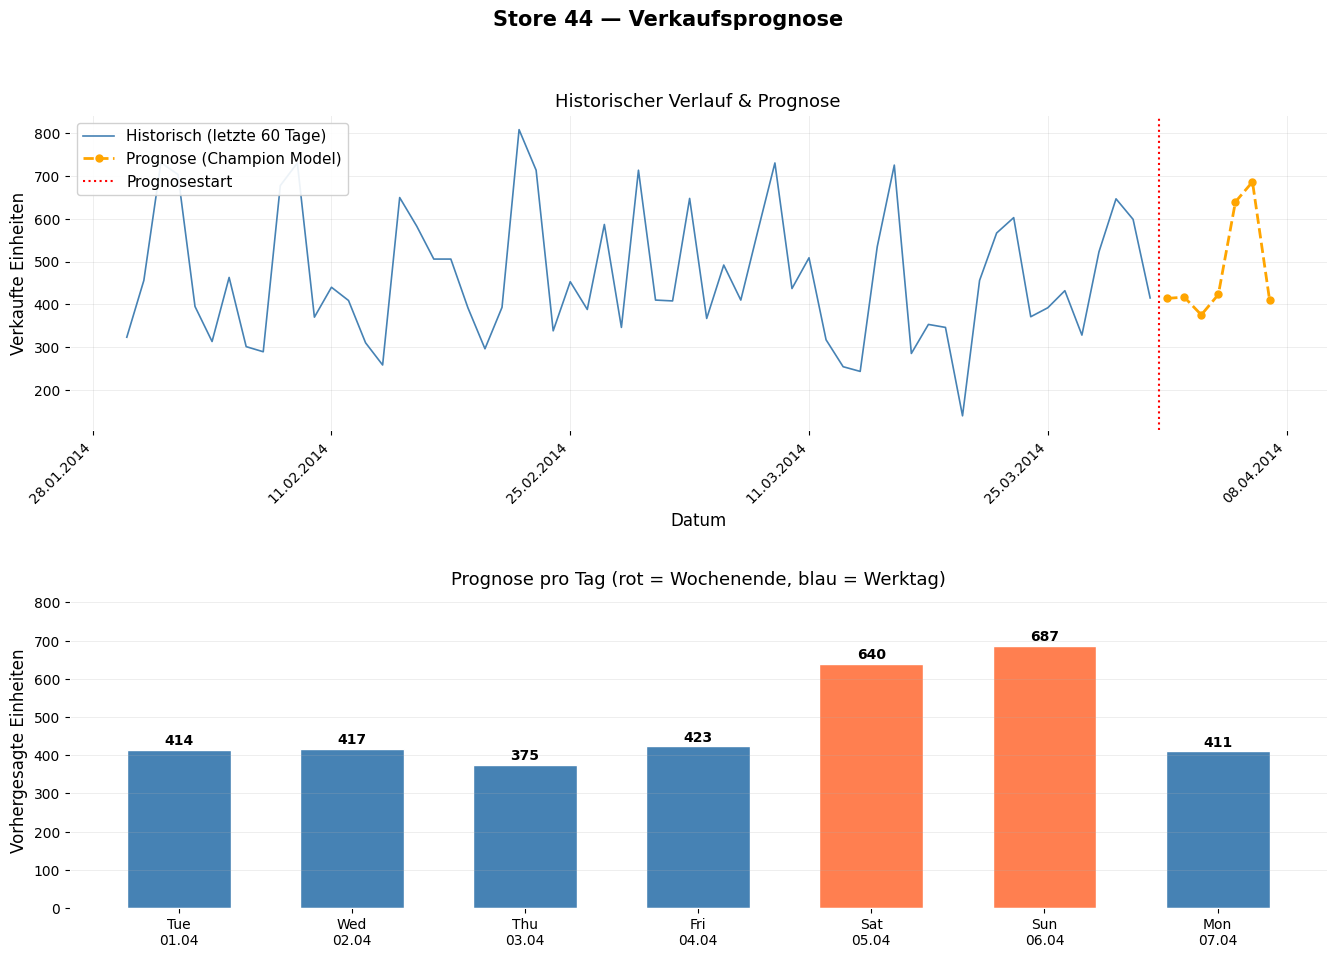

✅ Visualisierungs-Funktion getestet


In [4]:
# ============================================================
# ZELLE 4: Visualisierungs-Funktion
# Zwei Charts:
# 1. Historischer Verlauf + Prognose
# 2. Prognose-Tabelle als Balkendiagramm
# ============================================================

def plot_forecast(df_feat: pd.DataFrame,
                  forecast: pd.DataFrame,
                  history_days: int = 60) -> plt.Figure:
    """
    Erstellt einen kombinierten Plot:
    - Historischer Verlauf (letzte N Tage)
    - Prognose (blau gestrichelt)
    - Trennlinie zwischen Historie und Prognose

    Parameter:
        df_feat:      Feature-DataFrame mit unit_sales
        forecast:     Prognose-DataFrame (Index=date, Spalte=prediction)
        history_days: Anzahl historischer Tage im Plot

    Rückgabe:
        matplotlib Figure Objekt
    """
    # Historische Daten — letzte N Tage vor Prognosestart
    history_end   = forecast.index.min() - pd.Timedelta(days=1)
    history_start = history_end - pd.Timedelta(days=history_days)
    history       = df_feat.loc[history_start:history_end, 'unit_sales']

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle('Store 44 — Verkaufsprognose', fontsize=15, fontweight='bold')

    # --- Plot 1: Verlauf + Prognose ---
    ax1 = axes[0]
    ax1.plot(history.index, history.values,
             color='steelblue', linewidth=1.2,
             label=f'Historisch (letzte {history_days} Tage)')
    ax1.plot(forecast.index, forecast['prediction'].values,
             color='orange', linewidth=2, linestyle='--',
             marker='o', markersize=5,
             label='Prognose (Champion Model)')
    ax1.axvline(forecast.index.min() - pd.Timedelta(days=0.5),
                color='red', linestyle=':', linewidth=1.5,
                label='Prognosestart')
    ax1.set_title('Historischer Verlauf & Prognose', fontsize=13)
    ax1.set_ylabel('Verkaufte Einheiten', fontsize=12)
    ax1.set_xlabel('Datum', fontsize=12)
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: Prognose Balkendiagramm ---
    ax2 = axes[1]
    colors = ['coral' if d.dayofweek >= 5 else 'steelblue'
              for d in forecast.index]
    bars = ax2.bar(range(len(forecast)),
                   forecast['prediction'].values,
                   color=colors, edgecolor='white', width=0.6)

    # Werte über Balken
    for bar, val in zip(bars, forecast['prediction'].values):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 f'{val:.0f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax2.set_xticks(range(len(forecast)))
    ax2.set_xticklabels(
        [d.strftime('%a\n%d.%m') for d in forecast.index],
        fontsize=10
    )
    ax2.set_title('Prognose pro Tag (rot = Wochenende, blau = Werktag)', fontsize=13)
    ax2.set_ylabel('Vorhergesagte Einheiten', fontsize=12)
    ax2.set_ylim(0, forecast['prediction'].max() * 1.2)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout(pad=3.0)
    return fig


# --- Funktion testen ---
fig = plot_forecast(df_feat, forecast_n, history_days=60)
plt.savefig('../data/plots/plot16_app_test_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisierungs-Funktion getestet")

In [5]:
# ============================================================
# ZELLE 5: CSV-Export Funktion + Gesamttest
# ============================================================

def forecast_to_csv(forecast: pd.DataFrame) -> str:
    """
    Konvertiert Prognose-DataFrame in CSV-String für Download.

    Parameter:
        forecast: DataFrame mit Index=date, Spalte=prediction

    Rückgabe:
        CSV-String (für Streamlit st.download_button)
    """
    export = forecast.copy()
    export.index.name = 'Datum'
    export.columns    = ['Prognose (Einheiten)']
    export['Wochentag'] = export.index.strftime('%A')
    export['Prognose (Einheiten)'] = export['Prognose (Einheiten)'].round(0).astype(int)
    return export.to_csv(encoding='utf-8-sig')


def forecast_summary(forecast: pd.DataFrame) -> dict:
    """
    Berechnet Kennzahlen der Prognose für Dashboard-Anzeige.

    Parameter:
        forecast: DataFrame mit Spalte 'prediction'

    Rückgabe:
        Dictionary mit Kennzahlen
    """
    return {
        'Zeitraum':          f"{forecast.index.min().strftime('%d.%m.%Y')} — {forecast.index.max().strftime('%d.%m.%Y')}",
        'Anzahl Tage':       len(forecast),
        'Gesamt (Einheiten)': int(forecast['prediction'].sum().round(0)),
        'Durchschnitt/Tag':  round(float(forecast['prediction'].mean()), 1),
        'Maximum':           int(forecast['prediction'].max().round(0)),
        'Minimum':           int(forecast['prediction'].min().round(0)),
        'Wochenende-Anteil': f"{(forecast['prediction'][forecast.index.dayofweek >= 5].sum() / forecast['prediction'].sum() * 100):.1f}%",
    }


# --- Gesamttest aller Funktionen ---
print("=" * 55)
print("GESAMTTEST — APP LOGIK")
print("=" * 55)

# 1. Feature Engineering
df_feat = build_features(df, df_oil, df_holiday)
print(f"✅ build_features():     {len(df_feat)} Zeilen, {len(FEATURE_COLS)} Features")

# 2. Einzeltag-Prognose
pred = predict_single_day(model, df_feat, pd.Timestamp('2014-03-31'))
print(f"✅ predict_single_day(): {pred:.1f} Einheiten")

# 3. N-Tages-Prognose
fc = predict_n_days(model, df_feat, pd.Timestamp('2014-04-01'),
                    7, df_oil, df_holiday)
print(f"✅ predict_n_days():     {len(fc)} Tage prognostiziert")

# 4. Visualisierung
fig = plot_forecast(df_feat, fc, history_days=60)
plt.close(fig)
print(f"✅ plot_forecast():      Figure erstellt")

# 5. CSV Export
csv_string = forecast_to_csv(fc)
print(f"✅ forecast_to_csv():    {len(csv_string)} Zeichen")

# 6. Summary
summary = forecast_summary(fc)
print(f"✅ forecast_summary():")
for key, val in summary.items():
    print(f"   {key:<25} {val}")

print(f"\n{'=' * 55}")
print("ALLE FUNKTIONEN BEREIT FUER app.py")
print("=" * 55)

GESAMTTEST — APP LOGIK
✅ build_features():     440 Zeilen, 15 Features
✅ predict_single_day(): 400.6 Einheiten
✅ predict_n_days():     7 Tage prognostiziert
✅ plot_forecast():      Figure erstellt
✅ forecast_to_csv():    207 Zeichen
✅ forecast_summary():
   Zeitraum                  01.04.2014 — 07.04.2014
   Anzahl Tage               7
   Gesamt (Einheiten)        3367
   Durchschnitt/Tag          481.0
   Maximum                   687
   Minimum                   375
   Wochenende-Anteil         39.4%

ALLE FUNKTIONEN BEREIT FUER app.py


## Double-Check: Schulungsanforderungen vs. aktueller Stand

### Pflichtanforderungen Woche 4

| Anforderung | Status | Bemerkung |
|---|---|---|
| app_test.ipynb erstellt | ✅ | Erledigt |
| Alle App-Funktionen im Notebook getestet | ✅ | 5 Funktionen getestet |
| Champion Model laden | ✅ | RF HyperOpt via joblib |
| Forecasting in der App | ✅ | Einzeltag + N-Tage |
| app.py erstellen | ⏳ | Noch ausstehend |
| requirements.txt erstellen | ⏳ | Noch ausstehend |
| README.md erstellen | ⏳ | Noch ausstehend |
| GitHub Upload | ⏳ | Noch ausstehend |

### Bewertungskriterien (aus Schulungsdokumentation)

| Kriterium | Status | Bemerkung |
|---|---|---|
| Geschäftsproblem klar erklärbar | ✅ | Store 44 Bestandsplanung |
| Prognosen unterstützen Entscheidungen | ✅ | Chart + Tabelle + CSV |
| Einzeltag-Prognose | ✅ | getestet |
| N-Tage-Prognose (autoregressive) | ✅ | getestet |
| Plot: Verlauf + Prognose | ✅ | getestet |
| CSV-Download | ✅ | getestet |

### Noch fehlende Schritte

1. **app.py** — Streamlit UI Code
2. **requirements.txt** — Abhängigkeiten
3. **README.md** — Projektdokumentation
4. **GitHub** — Code hochladen